In [13]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import ops

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [14]:
ROOT_DIR = r"E:\WISDM_ar_v1.1"

ABLATION_ROOT = os.path.join(ROOT_DIR, "ABLATION_STUDY")

WISDM_OUT = os.path.join(ABLATION_ROOT, "WISDM")

DIRS = {
    "models": os.path.join(WISDM_OUT, "models"),
    "reports": os.path.join(WISDM_OUT, "reports"),
    "plots": os.path.join(WISDM_OUT, "plots"),
}

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [15]:
WISDM_FILE = os.path.join(
    ROOT_DIR,
    "WISDM_ar_v1.1_raw.txt"
)

LABELS = [
    "Downstairs",
    "Jogging",
    "Sitting",
    "Standing",
    "Upstairs",
    "Walking"
]

label2idx = {lab: i for i, lab in enumerate(LABELS)}

rows = []

with open(WISDM_FILE, "r") as f:

    for line in f:

        line = line.strip()

        if not line:
            continue

        if line.endswith(";"):
            line = line[:-1]

        parts = line.split(",")

        if len(parts) != 6:
            continue

        user, act, ts, x, y, z = parts

        if act not in label2idx:
            continue

        rows.append([user, act, ts, x, y, z])

df = pd.DataFrame(
    rows,
    columns=[
        "user",
        "activity",
        "timestamp",
        "x",
        "y",
        "z"
    ]
)

for c in ["timestamp", "x", "y", "z"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df.dropna(inplace=True)

df = df[df["timestamp"] > 0]

df.sort_values(["user", "timestamp"], inplace=True)

df.reset_index(drop=True, inplace=True)

print(df.shape)

df.head()

(1073623, 6)


,user,activity,timestamp,x,y,z
0,1,Walking,4991922345000,0.69,10.80,-2.03
1,1,Walking,4991972333000,6.85,7.44,-0.50
2,1,Walking,4992022351000,0.93,5.63,-0.50
3,1,Walking,4992072339000,-2.11,5.01,-0.69
4,1,Walking,4992122358000,-4.59,4.29,-1.95


In [16]:
FEATURES = ["x", "y", "z"]

WIN = 80
STEP = 40

Xw = []
yw = []

for user_id, sub in df.groupby("user", sort=False):

    X = sub[FEATURES].values.astype(np.float32)

    y = sub["activity"].map(label2idx).values.astype(np.int32)

    for i in range(0, len(X) - WIN + 1, STEP):

        xs = X[i:i+WIN]
        ys = y[i:i+WIN]

        label = np.bincount(ys).argmax()

        Xw.append(xs)
        yw.append(label)

Xw = np.array(Xw, dtype=np.float32)
yw = np.array(yw, dtype=np.int32)

print("Windows Shape:", Xw.shape)
print("Labels Shape:", yw.shape)

Windows Shape: (26786, 80, 3)
Labels Shape: (26786,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    Xw,
    yw,
    test_size=0.2,
    stratify=yw,
    random_state=SEED
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_test_s = scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

X_train_s = X_train_s.astype(np.float32)
X_test_s = X_test_s.astype(np.float32)

print("Train:", X_train_s.shape)
print("Test:", X_test_s.shape)

Train: (21428, 80, 3)
Test: (5358, 80, 3)


In [18]:
def encoder_block(
    x,
    d_model,
    num_heads,
    mlp_dim,
    dropout
):

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout
    )(x, x)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x + attn)

    ff = layers.Dense(
        mlp_dim,
        activation="gelu"
    )(x)

    ff = layers.Dropout(dropout)(ff)

    ff = layers.Dense(d_model)(ff)

    ff = layers.Dropout(dropout)(ff)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x + ff)

    return x

In [19]:
def build_transformer(
    input_shape,
    num_classes,
    patch_len,
    depth
):

    d_model = 64
    num_heads = 4
    mlp_dim = 128
    dropout = 0.15

    inp = keras.Input(shape=input_shape)

    x = layers.Conv1D(
        filters=d_model,
        kernel_size=patch_len,
        strides=patch_len,
        padding="valid"
    )(inp)

    seq_len = ops.shape(x)[1]

    pos = ops.arange(
        start=0,
        stop=seq_len,
        step=1
    )

    pos_emb = layers.Embedding(
        input_dim=2048,
        output_dim=d_model
    )(pos)

    pos_emb = ops.expand_dims(pos_emb, axis=0)

    x = x + pos_emb

    x = layers.Dropout(dropout)(x)

    for _ in range(depth):

        x = encoder_block(
            x,
            d_model=d_model,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=dropout
        )

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dropout(dropout)(x)

    out = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [20]:
PATCH_LIST = [1, 2, 4, 8, 16, 32]

DEPTH_LIST = [1, 2, 3, 4]

configs = []

for patch_len in PATCH_LIST:

    for depth in DEPTH_LIST:

        name = f"Patch{patch_len}_Depth{depth}"

        if patch_len == 1:
            name = f"NoPatch_Depth{depth}"

        configs.append({
            "name": name,
            "patch_len": patch_len,
            "depth": depth
        })

print("Total Experiments:", len(configs))

configs[:5]

Total Experiments: 24


[{'name': 'NoPatch_Depth1', 'patch_len': 1, 'depth': 1},
 {'name': 'NoPatch_Depth2', 'patch_len': 1, 'depth': 2},
 {'name': 'NoPatch_Depth3', 'patch_len': 1, 'depth': 3},
 {'name': 'NoPatch_Depth4', 'patch_len': 1, 'depth': 4},
 {'name': 'Patch2_Depth1', 'patch_len': 2, 'depth': 1}]

In [21]:
def evaluate_model(model):

    probs = model.predict(
        X_test_s,
        verbose=0
    )

    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test, preds)

    f1 = f1_score(
        y_test,
        preds,
        average="macro"
    )

    return acc, f1


def measure_latency(model):

    sample = X_test_s[:1]

    # warmup
    for _ in range(10):
        model.predict(sample, verbose=0)

    start = time.time()

    for _ in range(100):
        model.predict(sample, verbose=0)

    end = time.time()

    latency = ((end - start) / 100) * 1000

    return latency

In [22]:
results = []

for cfg in configs:

    print("\n" + "="*80)
    print("Training:", cfg["name"])
    print("="*80)

    tf.keras.backend.clear_session()

    model = build_transformer(
        input_shape=X_train_s.shape[1:],
        num_classes=6,
        patch_len=cfg["patch_len"],
        depth=cfg["depth"]
    )

    callbacks = [

        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        X_train_s,
        y_train,
        validation_split=0.1,
        epochs=20,
        batch_size=128,
        callbacks=callbacks,
        verbose=1
    )

    acc, f1 = evaluate_model(model)

    latency = measure_latency(model)

    # Save model
    model_path = os.path.join(
        DIRS["models"],
        cfg["name"] + ".keras"
    )

    model.save(model_path)

    size_kb = os.path.getsize(model_path) / 1024

    params = model.count_params()

    results.append({

        "Configuration": cfg["name"],

        "Patch Length": cfg["patch_len"],

        "Encoder Layers": cfg["depth"],

        "Accuracy (%)": round(acc * 100, 2),

        "Macro F1 (%)": round(f1 * 100, 2),

        "Latency (ms)": round(latency, 2),

        "Model Size (KB)": round(size_kb, 2),

        "Parameters": params
    })

    temp_df = pd.DataFrame(results)

    running_csv = os.path.join(
        DIRS["reports"],
        "WISDM_RUNNING_RESULTS.csv"
    )

    temp_df.to_csv(running_csv, index=False)

    print(temp_df.tail(1))


Training: NoPatch_Depth1
Epoch 1/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.7349 - loss: 0.8012 - val_accuracy: 0.8409 - val_loss: 0.5118 - learning_rate: 0.0010
Epoch 2/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8297 - loss: 0.5052 - val_accuracy: 0.8656 - val_loss: 0.4178 - learning_rate: 0.0010
Epoch 3/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8525 - loss: 0.4293 - val_accuracy: 0.8810 - val_loss: 0.3673 - learning_rate: 0.0010
Epoch 4/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8701 - loss: 0.3851 - val_accuracy: 0.8922 - val_loss: 0.3366 - learning_rate: 0.0010
Epoch 5/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.8793 - loss: 0.3567 - val_accuracy: 0.9062 - val_loss: 0.3089 - learning_rate: 0.0010
Epoch 6/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8919 - loss: 0.3245 - val_accuracy: 0.9127 - val_loss: 0.2888 - learning_rate: 0.0010
Epoch 7/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/s

In [23]:
results_df = pd.DataFrame(results)

final_csv = os.path.join(
    DIRS["reports"],
    "WISDM_FINAL_RESULTS.csv"
)

results_df.to_csv(final_csv, index=False)

print("Saved:", final_csv)

results_df

Saved: E:\WISDM_ar_v1.1\ABLATION_STUDY\WISDM\reports\WISDM_FINAL_RESULTS.csv


,Configuration,Patch Length,Encoder Layers,Accuracy (%),Macro F1 (%),Latency (ms),Model Size (KB),Parameters
0,NoPatch_Depth1,1,1,94.06,92.25,122.91,590.20,34118
1,NoPatch_Depth2,1,2,96.17,94.83,134.68,1030.50,67590
2,NoPatch_Depth3,1,3,97.13,95.93,127.06,1472.45,101062
3,NoPatch_Depth4,1,4,97.16,95.98,134.99,1912.93,134534
4,Patch2_Depth1,2,1,95.41,93.84,130.72,537.12,34310
5,Patch2_Depth2,2,2,96.66,95.36,127.40,977.27,67782
6,Patch2_Depth3,2,3,97.26,96.16,136.62,1419.27,101254
7,Patch2_Depth4,2,4,97.59,96.60,130.16,1859.80,134726
8,Patch4_Depth1,4,1,95.35,93.66,120.82,513.85,34694
9,Patch4_Depth2,4,2,96.45,94.81,130.50,954.09,68166


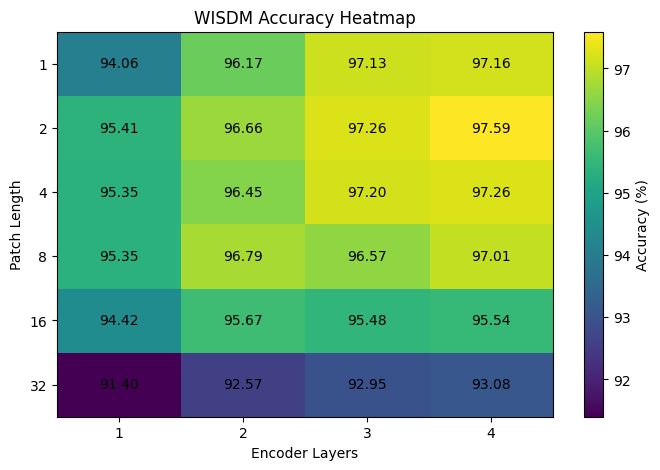

Saved: E:\WISDM_ar_v1.1\ABLATION_STUDY\WISDM\plots\WISDM_ACCURACY_HEATMAP.png


In [24]:
pivot_acc = results_df.pivot(
    index="Patch Length",
    columns="Encoder Layers",
    values="Accuracy (%)"
)

plt.figure(figsize=(8,5))

plt.imshow(pivot_acc, aspect="auto")

plt.xticks(
    range(len(pivot_acc.columns)),
    pivot_acc.columns
)

plt.yticks(
    range(len(pivot_acc.index)),
    pivot_acc.index
)

for i in range(len(pivot_acc.index)):

    for j in range(len(pivot_acc.columns)):

        plt.text(
            j,
            i,
            f"{pivot_acc.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.xlabel("Encoder Layers")

plt.ylabel("Patch Length")

plt.title("WISDM Accuracy Heatmap")

plt.colorbar(label="Accuracy (%)")

plot_path = os.path.join(
    DIRS["plots"],
    "WISDM_ACCURACY_HEATMAP.png"
)

plt.savefig(
    plot_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved:", plot_path)

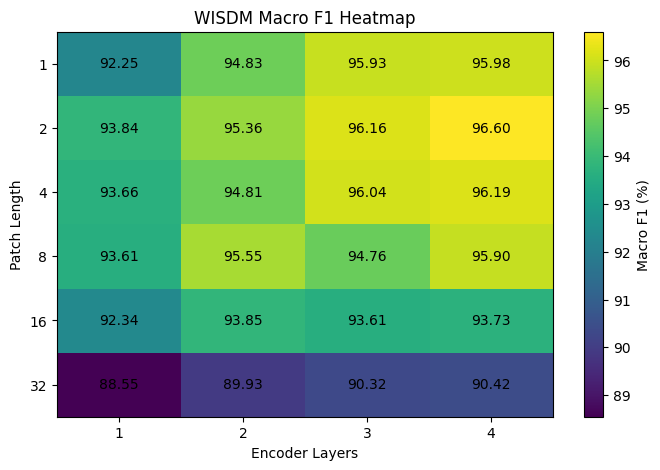

Saved: E:\WISDM_ar_v1.1\ABLATION_STUDY\WISDM\plots\WISDM_MACRO_F1_HEATMAP.png


In [25]:
pivot_f1 = results_df.pivot(
    index="Patch Length",
    columns="Encoder Layers",
    values="Macro F1 (%)"
)

plt.figure(figsize=(8,5))

plt.imshow(pivot_f1, aspect="auto")

plt.xticks(
    range(len(pivot_f1.columns)),
    pivot_f1.columns
)

plt.yticks(
    range(len(pivot_f1.index)),
    pivot_f1.index
)

for i in range(len(pivot_f1.index)):

    for j in range(len(pivot_f1.columns)):

        plt.text(
            j,
            i,
            f"{pivot_f1.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.xlabel("Encoder Layers")

plt.ylabel("Patch Length")

plt.title("WISDM Macro F1 Heatmap")

plt.colorbar(label="Macro F1 (%)")

plot_path = os.path.join(
    DIRS["plots"],
    "WISDM_MACRO_F1_HEATMAP.png"
)

plt.savefig(
    plot_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved:", plot_path)

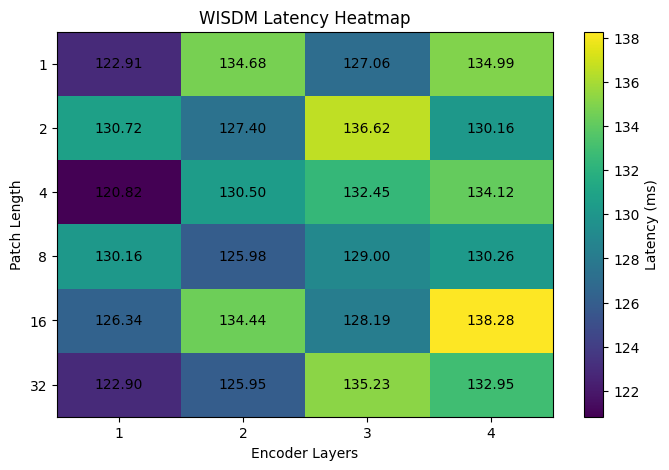

Saved: E:\WISDM_ar_v1.1\ABLATION_STUDY\WISDM\plots\WISDM_LATENCY_HEATMAP.png


In [26]:
pivot_latency = results_df.pivot(
    index="Patch Length",
    columns="Encoder Layers",
    values="Latency (ms)"
)

plt.figure(figsize=(8,5))

plt.imshow(pivot_latency, aspect="auto")

plt.xticks(
    range(len(pivot_latency.columns)),
    pivot_latency.columns
)

plt.yticks(
    range(len(pivot_latency.index)),
    pivot_latency.index
)

for i in range(len(pivot_latency.index)):

    for j in range(len(pivot_latency.columns)):

        plt.text(
            j,
            i,
            f"{pivot_latency.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.xlabel("Encoder Layers")

plt.ylabel("Patch Length")

plt.title("WISDM Latency Heatmap")

plt.colorbar(label="Latency (ms)")

plot_path = os.path.join(
    DIRS["plots"],
    "WISDM_LATENCY_HEATMAP.png"
)

plt.savefig(
    plot_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved:", plot_path)

In [27]:
# ============================================================
# CELL 15 — Load Best Balanced WISDM Model: Patch8_Depth2
# ============================================================

BEST_CONFIG = "Patch8_Depth2"

best_model_path = os.path.join(
    DIRS["models"],
    BEST_CONFIG + ".keras"
)

best_model = keras.models.load_model(best_model_path)

print("Loaded model:", best_model_path)
best_model.summary()

Loaded model: E:\WISDM_ar_v1.1\ABLATION_STUDY\WISDM\models\Patch8_Depth2.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 80, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 10, 64)    │      1,600 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 64)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     16,640 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 64)    │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10, 64)    │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 10, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 10, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10, 64)    │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 10, 64)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 206,804 (807.83 KB)

 Trainable params: 68,934 (269.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 137,870 (538.56 KB)

In [28]:
# ============================================================
# CELL 16 — TFLite Conversion Functions
# ============================================================

import tempfile

def convert_to_tflite(model, quant_type="fp32", representative_data=None):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    if quant_type == "fp32":
        pass

    elif quant_type == "fp16":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

    elif quant_type == "int8_dynamic":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]

    elif quant_type == "int8_full":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]

        def representative_dataset():
            for i in range(min(300, len(representative_data))):
                yield [representative_data[i:i+1].astype(np.float32)]

        converter.representative_dataset = representative_dataset
        converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS_INT8
        ]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8

    return converter.convert()

In [29]:
# ============================================================
# CELL 17 — TFLite Evaluation + Latency
# ============================================================

def evaluate_tflite_model(tflite_model, X_test, y_test):
    with tempfile.NamedTemporaryFile(suffix=".tflite", delete=False) as f:
        f.write(tflite_model)
        temp_model_path = f.name

    interpreter = tf.lite.Interpreter(model_path=temp_model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    preds = []

    for i in range(len(X_test)):
        x = X_test[i:i+1].astype(np.float32)

        if input_details[0]["dtype"] == np.int8:
            scale, zero_point = input_details[0]["quantization"]
            x = x / scale + zero_point
            x = np.clip(x, -128, 127).astype(np.int8)

        interpreter.set_tensor(input_details[0]["index"], x)
        interpreter.invoke()

        out = interpreter.get_tensor(output_details[0]["index"])

        if output_details[0]["dtype"] == np.int8:
            scale, zero_point = output_details[0]["quantization"]
            out = scale * (out.astype(np.float32) - zero_point)

        preds.append(np.argmax(out))

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")

    return acc, f1


def measure_tflite_latency(tflite_model, X_test, warmup=30, runs=300):
    with tempfile.NamedTemporaryFile(suffix=".tflite", delete=False) as f:
        f.write(tflite_model)
        temp_model_path = f.name

    interpreter = tf.lite.Interpreter(model_path=temp_model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()

    x = X_test[:1].astype(np.float32)

    if input_details[0]["dtype"] == np.int8:
        scale, zero_point = input_details[0]["quantization"]
        x = x / scale + zero_point
        x = np.clip(x, -128, 127).astype(np.int8)

    for _ in range(warmup):
        interpreter.set_tensor(input_details[0]["index"], x)
        interpreter.invoke()

    start = time.time()

    for _ in range(runs):
        interpreter.set_tensor(input_details[0]["index"], x)
        interpreter.invoke()

    end = time.time()

    latency = ((end - start) / runs) * 1000

    return latency

In [30]:
# ============================================================
# CELL 18 — Quantization Study for Patch8_Depth2
# ============================================================

TFLITE_DIR = os.path.join(WISDM_OUT, "tflite")
os.makedirs(TFLITE_DIR, exist_ok=True)

quant_results = []

# Add Keras FP32 baseline for same model
keras_acc, keras_f1 = evaluate_model(best_model)
keras_latency = measure_latency(best_model)

keras_size_kb = os.path.getsize(best_model_path) / 1024

quant_results.append({
    "Configuration": BEST_CONFIG,
    "Variant": "KERAS_FP32",
    "Patch Length": 8,
    "Encoder Layers": 2,
    "Accuracy (%)": round(keras_acc * 100, 2),
    "Macro F1 (%)": round(keras_f1 * 100, 2),
    "Latency (ms)": round(keras_latency, 2),
    "Model Size (KB)": round(keras_size_kb, 2),
    "Compression Ratio": round(keras_size_kb / keras_size_kb, 2)
})

for qtype in ["fp32", "fp16", "int8_dynamic", "int8_full"]:

    print("\nConverting:", qtype)

    tflite_model = convert_to_tflite(
        best_model,
        quant_type=qtype,
        representative_data=X_train_s
    )

    tflite_path = os.path.join(
        TFLITE_DIR,
        f"{BEST_CONFIG}_{qtype}.tflite"
    )

    with open(tflite_path, "wb") as f:
        f.write(tflite_model)

    acc, f1 = evaluate_tflite_model(
        tflite_model,
        X_test_s,
        y_test
    )

    latency = measure_tflite_latency(
        tflite_model,
        X_test_s
    )

    size_kb = os.path.getsize(tflite_path) / 1024

    quant_results.append({
        "Configuration": BEST_CONFIG,
        "Variant": f"TFLITE_{qtype.upper()}",
        "Patch Length": 8,
        "Encoder Layers": 2,
        "Accuracy (%)": round(acc * 100, 2),
        "Macro F1 (%)": round(f1 * 100, 2),
        "Latency (ms)": round(latency, 2),
        "Model Size (KB)": round(size_kb, 2),
        "Compression Ratio": round(keras_size_kb / size_kb, 2)
    })

    print(quant_results[-1])


Converting: fp32
INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpyitgolyb\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpyitgolyb\assets


Saved artifact at 'C:\Users\user\AppData\Local\Temp\tmpyitgolyb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2200748158864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748159440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200858513040: TensorSpec(shape=(1, 10, 64), dtype=tf.float32, name=None)
  2200748159632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748159056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748161360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748159824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748161744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748161552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748160976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  22007

e:\WISDM_ar_v1.1\aasif_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
e:\WISDM_ar_v1.1\aasif_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


{'Configuration': 'Patch8_Depth2', 'Variant': 'TFLITE_FP32', 'Patch Length': 8, 'Encoder Layers': 2, 'Accuracy (%)': 96.79, 'Macro F1 (%)': 95.55, 'Latency (ms)': 0.11, 'Model Size (KB)': 295.2, 'Compression Ratio': 3.22}

Converting: fp16
INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmprl5r2lp4\assets


...

INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpxnp0gl17\assets


Saved artifact at 'C:\Users\user\AppData\Local\Temp\tmpxnp0gl17'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2200748158864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748159440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200858513040: TensorSpec(shape=(1, 10, 64), dtype=tf.float32, name=None)
  2200748159632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748159056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748161360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748159824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748161744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748161552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2200748160976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  22007

e:\WISDM_ar_v1.1\aasif_env\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
e:\WISDM_ar_v1.1\aasif_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


{'Configuration': 'Patch8_Depth2', 'Variant': 'TFLITE_INT8_FULL', 'Patch Length': 8, 'Encoder Layers': 2, 'Accuracy (%)': 96.79, 'Macro F1 (%)': 95.54, 'Latency (ms)': 0.43, 'Model Size (KB)': 116.45, 'Compression Ratio': 8.15}


e:\WISDM_ar_v1.1\aasif_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [31]:
# ============================================================
# CELL 19 — Save Quantization Results
# ============================================================

quant_df = pd.DataFrame(quant_results)

quant_csv = os.path.join(
    DIRS["reports"],
    "WISDM_Patch8_Depth2_QUANTIZATION_RESULTS.csv"
)

quant_df.to_csv(quant_csv, index=False)

print("Saved:", quant_csv)

quant_df

Saved: E:\WISDM_ar_v1.1\ABLATION_STUDY\WISDM\reports\WISDM_Patch8_Depth2_QUANTIZATION_RESULTS.csv


,Configuration,Variant,Patch Length,Encoder Layers,Accuracy (%),Macro F1 (%),Latency (ms),Model Size (KB),Compression Ratio
0,Patch8_Depth2,KERAS_FP32,8,2,96.79,95.55,127.14,949.24,1.00
1,Patch8_Depth2,TFLITE_FP32,8,2,96.79,95.55,0.11,295.20,3.22
2,Patch8_Depth2,TFLITE_FP16,8,2,96.79,95.55,0.11,163.55,5.80
3,Patch8_Depth2,TFLITE_INT8_DYNAMIC,8,2,96.83,95.58,0.08,109.97,8.63
4,Patch8_Depth2,TFLITE_INT8_FULL,8,2,96.79,95.54,0.43,116.45,8.15


In [32]:
# ============================================================
# CELL 20 — Merge Grid Ablation + Quantization Study
# ============================================================

grid_df = pd.read_csv(
    os.path.join(DIRS["reports"], "WISDM_FINAL_RESULTS.csv")
)

grid_df["Variant"] = "KERAS_FP32"

grid_df = grid_df[
    [
        "Configuration",
        "Variant",
        "Patch Length",
        "Encoder Layers",
        "Accuracy (%)",
        "Macro F1 (%)",
        "Latency (ms)",
        "Model Size (KB)",
        "Parameters"
    ]
]

quant_df_for_merge = quant_df.copy()
quant_df_for_merge["Parameters"] = ""

# avoid duplicate KERAS_FP32 row for Patch8_Depth2
quant_df_for_merge = quant_df_for_merge[
    quant_df_for_merge["Variant"] != "KERAS_FP32"
]

final_ablation_df = pd.concat(
    [grid_df, quant_df_for_merge],
    ignore_index=True
)

final_csv = os.path.join(
    DIRS["reports"],
    "WISDM_FINAL_GRID_PLUS_QUANTIZATION_ABLATION.csv"
)

final_ablation_df.to_csv(final_csv, index=False)

print("Saved final table:", final_csv)

final_ablation_df

Saved final table: E:\WISDM_ar_v1.1\ABLATION_STUDY\WISDM\reports\WISDM_FINAL_GRID_PLUS_QUANTIZATION_ABLATION.csv


,Configuration,Variant,Patch Length,Encoder Layers,Accuracy (%),Macro F1 (%),Latency (ms),Model Size (KB),Parameters,Compression Ratio
0,NoPatch_Depth1,KERAS_FP32,1,1,94.06,92.25,122.91,590.20,34118,NaN
1,NoPatch_Depth2,KERAS_FP32,1,2,96.17,94.83,134.68,1030.50,67590,NaN
2,NoPatch_Depth3,KERAS_FP32,1,3,97.13,95.93,127.06,1472.45,101062,NaN
3,NoPatch_Depth4,KERAS_FP32,1,4,97.16,95.98,134.99,1912.93,134534,NaN
4,Patch2_Depth1,KERAS_FP32,2,1,95.41,93.84,130.72,537.12,34310,NaN
5,Patch2_Depth2,KERAS_FP32,2,2,96.66,95.36,127.40,977.27,67782,NaN
6,Patch2_Depth3,KERAS_FP32,2,3,97.26,96.16,136.62,1419.27,101254,NaN
7,Patch2_Depth4,KERAS_FP32,2,4,97.59,96.60,130.16,1859.80,134726,NaN
8,Patch4_Depth1,KERAS_FP32,4,1,95.35,93.66,120.82,513.85,34694,NaN
9,Patch4_Depth2,KERAS_FP32,4,2,96.45,94.81,130.50,954.09,68166,NaN
